<a href="https://colab.research.google.com/github/mfernandasoni/RappiPlus_from_data_to_business_decisions/blob/main/RappiPlus_de_datos_a_decisiones_negocio_MFSC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarse con la estructura de los datasets del negocio antes de analizarlos.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np

In [ ]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog =pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [ ]:
# explorar datasets
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [ ]:
catalog.info()
catalog.head(7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [ ]:
marketing.info()
marketing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.


#### 1. Validar y convertir fechas al formato correcto

In [ ]:
# Convertir las columnas de orders y marketing a tipo fecha con pd.to_datetime()
orders['fecha_hora_pedido']= pd.to_datetime(orders['fecha_hora_pedido'], errors="coerce")
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25080 non-null  object        
 5   fuente_referencia   25070 non-null  object        
 6   nombre_producto     25070 non-null  object        
 7   categoria_producto  25020 non-null  object        
 8   cantidad            25050 non-null  float64       
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB


In [ ]:
marketing['fecha']=pd.to_datetime(marketing['fecha'],errors="coerce")
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


#### 2. Revisar variables numéricas (sin negativos o ceros inválidos)

In [ ]:
#Revisar dataset orders
orders.describe()

,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


**Reflexión:** Se revisaron las variables numéricas mediante estadísticos descriptivos, *precio_unitario* y *monto_descuento* no presentaron valores fuera de rangos lógicamente imposibles. Sin embargo, se detectaron valores anómalos en *cantidad*, incluyendo valores negativos y cantidades extremadamente altas. Estos registros también generan valores negativos o excepcionalmente altos en *monto_total*.

In [ ]:
#Calcular nulos, ceros inválidos y negativos
num_cols_orders=["cantidad", "precio_unitario", "monto_descuento", "monto_total"]
n_total_orders=len(orders)
resumen_orders=[]

for col in num_cols_orders:
    n_neg = (orders[col] < 0).sum()
    n_zero = (orders[col] == 0).sum()
    n_null = orders[col].isna().sum()
    resumen_orders.append({
        "columna": col,
        "negativos": n_neg,
        "% negativos": round(n_neg / n_total_orders * 100, 2),
        "ceros": n_zero,
        "% ceros": round(n_zero / n_total_orders * 100, 2),
        "nulos": n_null,
        "% nulos": round(n_null / n_total_orders * 100, 2),
    })

pd.DataFrame(resumen_orders)

,columna,negativos,% negativos,ceros,% ceros,nulos,% nulos
0,cantidad,4,0.02,0,0.0,50,0.2
1,precio_unitario,0,0.00,0,0.0,50,0.2
2,monto_descuento,0,0.00,12551,50.0,50,0.2
3,monto_total,4,0.02,0,0.0,0,0.0


In [ ]:
#Identificar los outliers
print("Cantidad mayor a 100:", (orders["cantidad"] > 100).sum())
print("Monto total mayor a 100,000:", (orders["monto_total"] > 100000).sum())

Cantidad mayor a 100: 10
Monto total mayor a 100,000: 10


In [ ]:
#Explorar los outliers
orders_outliers= orders[orders["cantidad"]>100]
orders_outliers

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.0
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.0
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.0
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.0
3656,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000.0,297.66,0.0,5953200.0
3668,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,348.31,0.0,6966200.0
3689,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.0
3722,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,442.01,0.0,8840200.0
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000.0,290.85,0.0,5817000.0
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.0


**Reflexión:**

Se identificaron 10 registros (0.04% del total de pedidos) con una cantidad solicitada de 10,000 o 20,000 unidades, muy por encima del resto del dataset (mediana de 2 unidades por línea). A diferencia de una variación aleatoria, estos valores son exactos y redondos, y comparten una característica en común: todos corresponden al producto Laptop-Gaming-16GB, aunque involucran a 10 usuarios distintos, sin coincidir en fecha, dispositivo, fuente de referencia ni país. El precio unitario de estos registros sí varía dentro de un rango normal, por lo que la inconsistencia se concentra únicamente en el campo cantidad.

Debido a que no se cuenta con información adicional (por ejemplo, un registro de conversión de unidades o de pedidos de mayoreo) que permita confirmar si esta cantidad es válida o corresponde a un error de captura o de sistema, se optó por no modificar ni eliminar los datos originales, preservando la integridad de la fuente cruda.

Sin embargo, estos 10 registros pueden influenciar el cálculo de los KPIs, por lo que se excluirán del análisis principal de KPIs y serán evaluados por aparte.


In [ ]:
#Revisar dataset catalog
catalog.describe()

,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


**Reflexión:** En *costo_unitario* no se detectaron valores negativos o iguales a cero. Los costos presentan un rango entre 10.12 y 280.68, por lo que no se identificaron valores lógicamente imposibles. La variabilidad observada entre productos es esperable y no constituye por sí misma un problema de calidad.

In [ ]:
#Revisar dataset marketing
marketing.describe()

,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


**Reflexión:** En *gasto* se revisaron los estadísticos descriptivos y no se identificaron valores negativos o iguales a cero. El gasto presenta un rango entre 501.11 y 2,999.36, sin valores lógicamente imposibles. La variabilidad observada se considera razonable para diferentes campañas de marketing.

#### 3. Verificar consistencia de montos

In [ ]:
# monto esperado = cantidad * precio_unitario - descuento
# Se conserva el signo para transacciones negativas
# Tolerancia de 1 centavo por redondeos

orders["monto_esperado"] = (
    np.sign(orders["cantidad"]) *
    (
        orders["cantidad"].abs() * orders["precio_unitario"]
        - orders["monto_descuento"]
    )
)

orders["diferencia"] = (
    orders["monto_total"] - orders["monto_esperado"]
).abs()

orders["es_coherente"] = orders["diferencia"] <= 0.01

print("\n=== Consistencia de montos ===")

print(
    f"Consistentes:   {orders['es_coherente'].sum()} "
    f"({orders['es_coherente'].mean()*100:.2f}%)"
)

print(
    f"Inconsistentes: {(~orders['es_coherente']).sum()} "
    f"({(~orders['es_coherente']).mean()*100:.2f}%)"
)


=== Consistencia de montos ===
Consistentes:   23904 (95.24%)
Inconsistentes: 1196 (4.76%)


In [ ]:
orders[
    ~orders["es_coherente"]
][
    [
        "cantidad",
        "precio_unitario",
        "monto_descuento",
        "monto_total",
        "monto_esperado",
        "diferencia"
    ]
].head(20)



,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia
2,2.0,102.99,10.0,195.99,195.98,0.01
24,2.0,117.99,0.0,235.99,235.98,0.01
35,2.0,467.34,5.0,929.69,929.68,0.01
41,2.0,37.77,10.0,65.53,65.54,0.01
74,NaN,NaN,NaN,595.85,NaN,NaN
75,NaN,NaN,NaN,458.15,NaN,NaN
76,NaN,NaN,NaN,319.75,NaN,NaN
77,NaN,NaN,NaN,227.55,NaN,NaN
78,NaN,NaN,NaN,432.39,NaN,NaN
79,NaN,NaN,NaN,527.15,NaN,NaN


In [ ]:
# Identificar si faltan datos necesarios para calcular el monto esperado
orders["datos_monto_completos"] = orders[
    ["cantidad", "precio_unitario", "monto_descuento", "monto_total"]
].notna().all(axis=1)

# Clasificación
orders["consistencia_monto"] = np.select(
    [
        ~orders["datos_monto_completos"],
        orders["diferencia"] <= 0.01
    ],
    [
        "No verificable - datos faltantes",
        "Consistente"
    ],
    default="Inconsistente"
)

resumen = orders["consistencia_monto"].value_counts()

total = len(orders)

print("\n=== Consistencia de montos ===")

for categoria, cantidad in resumen.items():
    porcentaje = cantidad / total * 100
    print(f"{categoria}: {cantidad} ({porcentaje:.2f}%)")

print(f"\nTotal de registros: {total}")






=== Consistencia de montos ===
Consistente: 23904 (95.24%)
Inconsistente: 1146 (4.57%)
No verificable - datos faltantes: 50 (0.20%)

Total de registros: 25100


In [ ]:
orders[orders["consistencia_monto"] == "Inconsistente"]["diferencia"].describe()

count    1.146000e+03
mean     1.000000e-02
std      3.709970e-14
min      1.000000e-02
25%      1.000000e-02
50%      1.000000e-02
75%      1.000000e-02
max      1.000000e-02
Name: diferencia, dtype: float64

**Reflexión:** El **95.25%** de los pedidos presenta **consistencia aritmética** entre cantidad, precio unitario, descuento y monto total. El **4.55%** presenta una **diferencia de $0.01**, atribuible preliminarmente a **redondeos**. El **0.20%** restante **no pudo verificarse debido a datos faltantes.**

#### 4. Valores Nulos y Duplicados

In [ ]:
#Diagnóstico por Dataset de valores nulos y duplicados

datasets = {
    "Orders": orders,
    "Catalog": catalog,
    "Marketing": marketing
}

for nombre, df in datasets.items():

    print("\n" + "=" * 60)
    print(f"DATASET: {nombre}")
    print("=" * 60)

    # Valores nulos
    print("\n--- Valores nulos ---")

    nulos = df.isna().sum()
    porcentaje_nulos = (nulos / len(df) * 100).round(2)

    resumen_nulos = pd.DataFrame({
        "nulos": nulos,
        "porcentaje": porcentaje_nulos
    })


    print(resumen_nulos[resumen_nulos["nulos"] > 0])

    # Duplicados
    print("\n--- Duplicados ---")
    duplicados = df.duplicated().sum()
    porcentaje_duplicados = duplicados / len(df) * 100

    print(
        f"Duplicados: {duplicados:,} "
        f"({porcentaje_duplicados:.2f}%)"
    )


DATASET: Orders

--- Valores nulos ---
                    nulos  porcentaje
pais                  300        1.20
dispositivo            20        0.08
fuente_referencia      30        0.12
nombre_producto        30        0.12
categoria_producto     80        0.32
cantidad               50        0.20
precio_unitario        50        0.20
monto_descuento        50        0.20
monto_esperado         50        0.20
diferencia             50        0.20

--- Duplicados ---
Duplicados: 100 (0.40%)

DATASET: Catalog

--- Valores nulos ---
Empty DataFrame
Columns: [nulos, porcentaje]
Index: []

--- Duplicados ---
Duplicados: 0 (0.00%)

DATASET: Marketing

--- Valores nulos ---
       nulos  porcentaje
canal    101        6.23

--- Duplicados ---
Duplicados: 0 (0.00%)


**Dataset Orders**

In [ ]:
# ¿Cuántos id_pedido están duplicados?
orders["id_pedido"].duplicated().sum()

100

In [ ]:
# Mostrar las filas completamente duplicadas
orders[orders.duplicated(keep=False)].sort_values("id_pedido")

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia,es_coherente,datos_monto_completos,consistencia_monto
25023,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67,442.68,0.01,True,True,Consistente
10082,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67,442.68,0.01,True,True,Consistente
25037,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10,160.10,0.00,True,True,Consistente
10709,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10,160.10,0.00,True,True,Consistente
25065,order_10829,user_7697,2025-01-23,Argentina,mobile,social,Phone-Pro-128GB,Electronica,2.0,115.54,0.0,231.08,231.08,0.00,True,True,Consistente
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25048,order_8326,user_6177,2025-06-14,Argentina,mobile,organic,Vacuum-Pro-Black,Hogar,1.0,457.53,0.0,457.53,457.53,0.00,True,True,Consistente
25043,order_8414,user_4073,2025-05-10,Colombia,mobile,social,Jacket-Winter-M,Moda,2.0,144.35,10.0,278.71,278.70,0.01,True,True,Consistente
8414,order_8414,user_4073,2025-05-10,Colombia,mobile,social,Jacket-Winter-M,Moda,2.0,144.35,10.0,278.71,278.70,0.01,True,True,Consistente
25056,order_974,user_3262,2025-05-04,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,2.0,268.58,5.0,532.16,532.16,0.00,True,True,Consistente


In [ ]:
#Eliminar duplicados de "Orders" y Validar
orders = orders.drop_duplicates(subset="id_pedido", keep="first").reset_index(drop=True)
print(f"Duplicados en Orders:", orders.duplicated(subset="id_pedido").sum())

Duplicados en Orders: 0


**Reflexión:** Se identificaron 100 registros duplicados en *Orders*, correspondientes a pedidos con id_pedido repetido y registros completamente idénticos. Se conservó una única instancia de cada pedido, resultando en 25,000 registros únicos.

In [ ]:
#Filas donde cantidad es un valor nulo
orders[orders['cantidad'].isna()]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia,es_coherente,datos_monto_completos,consistencia_monto
74,order_74,user_6172,2025-01-15,Argentina,desktop,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,595.85,NaN,NaN,False,False,No verificable - datos faltantes
75,order_75,user_6588,2025-06-19,Colombia,mobile,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,458.15,NaN,NaN,False,False,No verificable - datos faltantes
76,order_76,user_3193,2025-03-17,Argentina,mobile,paid_search,Laptop-Gaming-16GB,NaN,NaN,NaN,NaN,319.75,NaN,NaN,False,False,No verificable - datos faltantes
77,order_77,user_775,2025-06-24,Argentina,desktop,social,Vacuum-Pro-Black,NaN,NaN,NaN,NaN,227.55,NaN,NaN,False,False,No verificable - datos faltantes
78,order_78,user_2702,2025-03-19,Argentina,desktop,paid_search,Phone-Pro-128GB,NaN,NaN,NaN,NaN,432.39,NaN,NaN,False,False,No verificable - datos faltantes
79,order_79,user_6438,2025-03-22,Colombia,desktop,paid_search,Sneakers-Urban-42,NaN,NaN,NaN,NaN,527.15,NaN,NaN,False,False,No verificable - datos faltantes
80,order_80,user_6790,2025-01-03,Mexico,desktop,organic,Vacuum-Pro-Black,NaN,NaN,NaN,NaN,711.18,NaN,NaN,False,False,No verificable - datos faltantes
81,order_81,user_232,2025-05-16,Mexico,mobile,paid_search,Tablet-Standard-64GB,NaN,NaN,NaN,NaN,41.08,NaN,NaN,False,False,No verificable - datos faltantes
82,order_82,user_5665,2025-02-07,Colombia,mobile,paid_search,Sneakers-Urban-42,NaN,NaN,NaN,NaN,431.55,NaN,NaN,False,False,No verificable - datos faltantes
83,order_83,user_5225,2025-04-25,Argentina,mobile,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,279.35,NaN,NaN,False,False,No verificable - datos faltantes


**Reflexión:** Se observa que los 50 registros con valores nulos que tiene la columna de *cantidad* son los mismos para las columnas: *precio_unitario* y *monto_descuento*. Además que la columna *categoria_producto* también se encuentra vacía.

No existe información suficiente en las demás variables para recuperar la *cantidad*, *precio_unitario* y *monto_descuento* de productos de forma confiable, por lo que se conservan como valores nulos para evitar imputaciones arbitrarias que pudieran afectar el análisis de ventas.

La columna *categoria_producto* se puede recuperar con la información de *Catalog*.

In [ ]:
#Unión de Orders y Catalog
orders = pd.merge(orders, catalog,
    on="nombre_producto",
    how="left",
    suffixes=("", "_catalog"))
#orders[orders['cantidad'].isna()]
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia,es_coherente,datos_monto_completos,consistencia_monto,categoria_producto_catalog,costo_unitario,proveedor
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37,665.38,0.01,True,True,Consistente,Moda,189.31,Mcmillan-Rhodes
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86,171.86,0.00,True,True,Consistente,Electrónica,25.21,Bowers LLC
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99,195.98,0.01,False,True,Inconsistente,Hogar,176.64,Long-Reid
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87,242.87,0.00,True,True,Consistente,Electrónica,25.21,Bowers LLC
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28,336.28,0.00,True,True,Consistente,Hogar,176.64,Long-Reid


In [ ]:
#Rellenar categoria_producto con la categoria del catalogo
orders["categoria_producto"]=orders["categoria_producto"].fillna(orders["categoria_producto_catalog"])
orders[orders['cantidad'].isna()].head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia,es_coherente,datos_monto_completos,consistencia_monto,categoria_producto_catalog,costo_unitario,proveedor
74,order_74,user_6172,2025-01-15,Argentina,desktop,organic,Sneakers-Urban-42,Moda,NaN,NaN,NaN,595.85,NaN,NaN,False,False,No verificable - datos faltantes,Moda,17.21,Greene-Smith
75,order_75,user_6588,2025-06-19,Colombia,mobile,organic,Sneakers-Urban-42,Moda,NaN,NaN,NaN,458.15,NaN,NaN,False,False,No verificable - datos faltantes,Moda,17.21,Greene-Smith
76,order_76,user_3193,2025-03-17,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,NaN,NaN,NaN,319.75,NaN,NaN,False,False,No verificable - datos faltantes,Electrónica,280.68,"Fuller, Pena and Myers"
77,order_77,user_775,2025-06-24,Argentina,desktop,social,Vacuum-Pro-Black,Hogar,NaN,NaN,NaN,227.55,NaN,NaN,False,False,No verificable - datos faltantes,Hogar,16.60,"Rivera, Carr and Finley"
78,order_78,user_2702,2025-03-19,Argentina,desktop,paid_search,Phone-Pro-128GB,Electrónica,NaN,NaN,NaN,432.39,NaN,NaN,False,False,No verificable - datos faltantes,Electrónica,10.12,King Ltd


In [ ]:
# Revisar los 30 registros donde sigue faltando la categoría
orders[orders["categoria_producto"].isna()][[
    "id_pedido",
    "fuente_referencia",
    "nombre_producto",
    "precio_unitario",
    "cantidad",
    "monto_total"
]]

,id_pedido,fuente_referencia,nombre_producto,precio_unitario,cantidad,monto_total
44,order_44,NaN,NaN,318.38,1.0,313.38
45,order_45,NaN,NaN,354.06,2.0,698.12
46,order_46,NaN,NaN,359.31,1.0,349.31
47,order_47,NaN,NaN,476.78,2.0,953.56
48,order_48,NaN,NaN,137.96,2.0,275.93
49,order_49,NaN,NaN,433.76,2.0,867.53
50,order_50,NaN,NaN,495.38,1.0,490.38
51,order_51,NaN,NaN,382.94,2.0,765.89
52,order_52,NaN,NaN,415.01,2.0,830.01
53,order_53,NaN,NaN,236.49,2.0,472.98


**Reflexión:** Se observa que en los 30 registros donde *categoria_producto* esta ausente, también esta ausente *fuente_referencia* y *nombre_producto*. Estos registros no se pueden recuperar con algun dataset adicional. En este caso, se rellenarán como "desconocido" para no influir en el análisis y facilitar la visualización más adelante.

In [ ]:
#Rellenar valores nulos con "Desconocido"
orders["nombre_producto"] = (
    orders["nombre_producto"].fillna("Desconocido")
)

orders["categoria_producto"] = (
    orders["categoria_producto"].fillna("Desconocido")
)

orders["fuente_referencia"] = (
    orders["fuente_referencia"].fillna("Desconocido")
)

orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id_pedido                   25000 non-null  object        
 1   id_usuario                  25000 non-null  object        
 2   fecha_hora_pedido           25000 non-null  datetime64[ns]
 3   pais                        24700 non-null  object        
 4   dispositivo                 24980 non-null  object        
 5   fuente_referencia           25000 non-null  object        
 6   nombre_producto             25000 non-null  object        
 7   categoria_producto          25000 non-null  object        
 8   cantidad                    24950 non-null  float64       
 9   precio_unitario             24950 non-null  float64       
 10  monto_descuento             24950 non-null  float64       
 11  monto_total                 25000 non-null  float64   

In [ ]:
#Tratar los valores nulos de Dispositivo
orders["dispositivo"] = orders["dispositivo"].fillna("Desconocido")
orders["dispositivo"].value_counts(dropna=False)


desktop        12711
mobile         12269
Desconocido       20
Name: dispositivo, dtype: int64

**Reflexión:** Se rellena los valores nulos con "Desconocido" para poder ser identificados más adelante en el dashboard.

In [ ]:
#Tratar valores nulos de Pais
orders["pais"].value_counts()


Colombia     7481
Mexico       7478
Argentina    7259
mexico        863
colombia      823
argentina     796
Name: pais, dtype: int64

**Comentario:** Se detecta inconsistencias en los valores de paises. Para eso hay que normalizar esta columna.

In [ ]:
#Normalizar columna pais
orders["pais"] = orders["pais"].str.strip().str.title()
orders["pais"].value_counts(dropna=False)

Mexico       8341
Colombia     8304
Argentina    8055
NaN           300
Name: pais, dtype: int64

In [ ]:
#Número de usuarios únicos
orders["id_usuario"].nunique()

7642

In [ ]:
#Se crea nueva tabla para relacionar id_usuario con pais
usuarios_pais = orders[
    orders["pais"].notna()
][["id_usuario", "pais"]].drop_duplicates()

#Se observa cuantos paises hay por usuario
usuarios_pais.groupby("id_usuario")["pais"].nunique().value_counts()

1    7624
Name: pais, dtype: int64

**Comentario:** Se identificaron 7,642 usuarios únicos. De ellos, 7,624 cuentan con información de país y cada usuario está asociado a un único país. Los 18 usuarios restantes no cuentan con información de país disponible en sus registros.

In [ ]:
#Visualizar relación id_usuario con pais
usuarios_pais_serie = usuarios_pais.set_index("id_usuario")["pais"]
usuarios_pais_serie

id_usuario
user_6993    Argentina
user_1329       Mexico
user_3194    Argentina
user_4510     Colombia
user_5044    Argentina
               ...    
user_1231     Colombia
user_4569    Argentina
user_7965    Argentina
user_76       Colombia
user_670        Mexico
Name: pais, Length: 7624, dtype: object

In [ ]:
#Imputar paises en aquellas filas donde hace falta
pais_faltante = orders["pais"].isna()

orders.loc[pais_faltante, "pais"] = (
    orders.loc[pais_faltante, "id_usuario"]
    .map(usuarios_pais_serie)
)

#Verificar cuantos valores nulos siguen existiendo en Pais
nulos_antes = 300
nulos_despues = orders["pais"].isna().sum()

recuperados = nulos_antes - nulos_despues

print(f"Países recuperados: {recuperados}")
print(f"Países aún faltantes: {nulos_despues}")

Países recuperados: 281
Países aún faltantes: 19


In [ ]:
#Lo que no se puede recuperar se establece como "Desconocido"
orders["pais"] = orders["pais"].fillna("Desconocido")

#Verificar valores únicos de la columna pais
orders["pais"].value_counts()


Mexico         8440
Colombia       8386
Argentina      8155
Desconocido      19
Name: pais, dtype: int64

**Reflexión:** Se identificaron 300 registros con país ausente. Debido a que 7,624 usuarios cuentan con un único país registrado, fue posible recuperar el país de los pedidos faltantes utilizando el historial del usuario. Los registros correspondientes a usuarios sin información histórica de país se clasificaron como "Desconocido".

In [ ]:
#Reducimos el dataset a las columnas necesarias para el análisis
orders_clean = orders.drop(columns=[
    "monto_esperado",
    "diferencia",
    "categoria_producto_catalog",
    "costo_unitario",
    "proveedor"
])

orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_pedido              25000 non-null  object        
 1   id_usuario             25000 non-null  object        
 2   fecha_hora_pedido      25000 non-null  datetime64[ns]
 3   pais                   25000 non-null  object        
 4   dispositivo            25000 non-null  object        
 5   fuente_referencia      25000 non-null  object        
 6   nombre_producto        25000 non-null  object        
 7   categoria_producto     25000 non-null  object        
 8   cantidad               24950 non-null  float64       
 9   precio_unitario        24950 non-null  float64       
 10  monto_descuento        24950 non-null  float64       
 11  monto_total            25000 non-null  float64       
 12  es_coherente           25000 non-null  bool          
 13  d

**Dataset Marketing**

In [ ]:
marketing[marketing["canal"].isna()]

,fecha,pais,id_campaña,canal,gasto
98,2025-01-11,Argentina,social_Argentina,NaN,849.70
99,2025-01-12,Mexico,organic_Mexico,NaN,2033.56
100,2025-01-12,Mexico,paid_search_Mexico,NaN,1260.65
101,2025-01-12,Mexico,social_Mexico,NaN,1660.90
102,2025-01-12,Colombia,organic_Colombia,NaN,1819.27
...,...,...,...,...,...
194,2025-01-22,Colombia,social_Colombia,NaN,772.46
195,2025-01-22,Argentina,organic_Argentina,NaN,1562.61
196,2025-01-22,Argentina,paid_search_Argentina,NaN,644.34
197,2025-01-22,Argentina,social_Argentina,NaN,2544.66


In [ ]:
#Extraemos el canal de cada id_campaña
marketing["canal_recuperado"] = marketing["id_campaña"].str.extract(
    r"^(social|organic|paid_search)"
)
marketing["canal_recuperado"]

0           organic
1       paid_search
2            social
3           organic
4       paid_search
           ...     
1615    paid_search
1616         social
1617        organic
1618    paid_search
1619         social
Name: canal_recuperado, Length: 1620, dtype: object

In [ ]:
#Usamos ese valor solamente donde canal está vacío
marketing["canal"] = marketing["canal"].fillna(
    marketing["canal_recuperado"]
)

#Verificamos los nulos en canal
marketing["canal"].isna().sum()


0

In [ ]:
#Verificamos los valores de cada tipo de canal
marketing["canal"].value_counts()

social         540
paid_search    540
organic        540
Name: canal, dtype: int64

In [ ]:
#Eliminar columna auxiliar
marketing = marketing.drop(columns=["canal_recuperado"])
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


**Reflexión:** Se identificaron 101 registros con canal ausente. El canal pudo recuperarse a partir de id_campaña, ya que esta variable contiene explícitamente el tipo de campaña (social, organic y paid_search). Se utilizó esta relación para completar los valores faltantes sin realizar imputaciones arbitrarias.

#### 5. Revisar variables categóricas

**Dataset Orders_clean**

In [ ]:
orders_clean.nunique()

id_pedido                25000
id_usuario                7642
fecha_hora_pedido          181
pais                         4
dispositivo                  3
fuente_referencia            4
nombre_producto              8
categoria_producto           5
cantidad                     6
precio_unitario          19543
monto_descuento              4
monto_total              21536
es_coherente                 2
datos_monto_completos        2
consistencia_monto           3
dtype: int64

In [ ]:

#Revisar variable pais
orders_clean['pais'].value_counts()


Mexico         8440
Colombia       8386
Argentina      8155
Desconocido      19
Name: pais, dtype: int64

In [ ]:
#Revisar variable dispositivo
orders_clean['dispositivo'].value_counts()

desktop        12711
mobile         12269
Desconocido       20
Name: dispositivo, dtype: int64

In [ ]:
#Revisar variable fuente_referencia
orders_clean['fuente_referencia'].value_counts()

social         8402
organic        8288
paid_search    8280
Desconocido      30
Name: fuente_referencia, dtype: int64

In [ ]:

#Revisar variable nombre_producto
orders_clean['nombre_producto'].value_counts()


Blender-XL-Red          4179
Vacuum-Pro-Black        4176
Jacket-Winter-M         4176
Sneakers-Urban-42       4148
Laptop-Gaming-16GB      2782
Tablet-Standard-64GB    2769
Phone-Pro-128GB         2740
Desconocido               30
Name: nombre_producto, dtype: int64

In [ ]:
#Revisar variable categoria_producto
orders_clean['categoria_producto'].value_counts()

Hogar          8355
Moda           8324
Electronica    8279
Desconocido      30
Electrónica      12
Name: categoria_producto, dtype: int64

In [ ]:
#Normalizar variable categoria_producto
orders_clean["categoria_producto"] = orders_clean["categoria_producto"].replace(
    "Electronica",
    "Electrónica"
)

#Validar normalización
orders_clean["categoria_producto"].value_counts()

Hogar          8355
Moda           8324
Electrónica    8291
Desconocido      30
Name: categoria_producto, dtype: int64

**Reflexión:** Se detectó una inconsistencia de escritura en la variable *categoria_producto*: las categorías Electronica y Electrónica representan la misma categoría y únicamente difieren por el uso del acento. Se homologaron ambos valores bajo Electrónica. Los 30 registros clasificados como Desconocido se conservaron debido a que no fue posible identificar su categoría a partir de la información disponible.

**Dataset Catalog**

In [ ]:
#Revisar variable nombre_producto
catalog["nombre_producto"].value_counts()

Tablet-Standard-64GB    1
Sneakers-Urban-42       1
Jacket-Winter-M         1
Laptop-Gaming-16GB      1
Vacuum-Pro-Black        1
Blender-XL-Red          1
Phone-Pro-128GB         1
Name: nombre_producto, dtype: int64

In [ ]:
#Revisar variable categoria_producto
catalog["categoria_producto"].value_counts()

Electrónica    3
Moda           2
Hogar          2
Name: categoria_producto, dtype: int64

In [ ]:
#Revisar variable proveedor
catalog["proveedor"].value_counts()

Fuller, Pena and Myers     1
Mcmillan-Rhodes            1
King Ltd                   1
Long-Reid                  1
Rivera, Carr and Finley    1
Greene-Smith               1
Bowers LLC                 1
Name: proveedor, dtype: int64

**Reflexión:** Variables categóricas del dataset *catalog* normalizadas y limpias.

**Dataset Marketing**

In [ ]:
#Revisar variable pais
marketing["pais"].value_counts()


Mexico       540
Colombia     540
Argentina    540
Name: pais, dtype: int64

In [ ]:
#Revisar variable id_campaña
marketing["id_campaña"].value_counts()

organic_Colombia         180
paid_search_Mexico       180
paid_search_Argentina    180
organic_Mexico           180
paid_search_Colombia     180
organic_Argentina        180
social_Argentina         180
social_Colombia          180
social_Mexico            180
Name: id_campaña, dtype: int64

In [ ]:
#Revisar variable canal
marketing["canal"].value_counts(dropna=False)

social         540
paid_search    540
organic        540
Name: canal, dtype: int64

In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


**Reflexión:** Variables categóricas del dataset *marketing* normalizadas y limpias.

**Conclusión de la limpieza:** Se realizó un proceso de limpieza y validación de los datasets *orders*, *catalog* y *marketing*, incluyendo revisión de valores nulos, duplicados, tipos de datos, variables categóricas, valores imposibles, consistencia de montos e integridad entre tablas. Los valores faltantes fueron recuperados cuando existió información confiable para hacerlo y, cuando no fue posible, se conservaron como nulos o se clasificaron como "Desconocido". Asimismo, se homologaron categorías inconsistentes.

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders_clean.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

#### 1. Rentabilidad del negocio

De acuerdo con la limpieza de datos, los 10 outliers se excluirán de este análisis principal y serán analizados por aparte.

Se hace una prueba del impacto que tiene incluir y excluir los 80 registros (desconocido + nulos) en el análisis.

In [ ]:
# 1. Producto "Desconocido" (30 filas) -> sin costo posible
excl_desconocido = orders_clean["nombre_producto"] == "Desconocido"

# 2. Cantidad/precio nulos (50 filas) -> sin costo posible
excl_nulos = orders_clean["cantidad"].isna()

# 3. Outliers de cantidad (10 filas, Laptop-Gaming-16GB, 10k-20k unidades,
#    81.45% del ingreso) -> ver sección de Calidad de Datos
excl_outliers = orders_clean["cantidad"] > 100

n_inicial = len(orders_clean)
excluidos = excl_outliers #Solo se excluyen los outliers
excluidos_s80 = excl_desconocido | excl_outliers  | excl_nulos #Se excluyen outliers, desconocido y nulos

print(f"  - Producto Desconocido:        {excl_desconocido.sum()}")
print(f"  - Cantidad/precio nulos:       {excl_nulos.sum()}")
print(f"  - Outliers cantidad (>100):    {excl_outliers.sum()}")
#print(f"  - Total excluido:              {excluidos_s80.sum()}")

orders_kpi = orders_clean[~excluidos].copy()
orders_sin_80= orders_clean[~excluidos_s80].copy()

  - Producto Desconocido:        30
  - Cantidad/precio nulos:       50
  - Outliers cantidad (>100):    10


In [ ]:
#Revisar dataframe orders_kpi y orders_sin_80
orders_kpi.info()
orders_sin_80.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24990 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_pedido              24990 non-null  object        
 1   id_usuario             24990 non-null  object        
 2   fecha_hora_pedido      24990 non-null  datetime64[ns]
 3   pais                   24990 non-null  object        
 4   dispositivo            24990 non-null  object        
 5   fuente_referencia      24990 non-null  object        
 6   nombre_producto        24990 non-null  object        
 7   categoria_producto     24990 non-null  object        
 8   cantidad               24940 non-null  float64       
 9   precio_unitario        24940 non-null  float64       
 10  monto_descuento        24940 non-null  float64       
 11  monto_total            24990 non-null  float64       
 12  es_coherente           24990 non-null  bool          
 13  d

In [ ]:
# Merge entre orders_kpi y catalog para obtener costo unitario en la misma tabla
orders_kpi=pd.merge(orders_kpi, catalog[["nombre_producto","costo_unitario"]], on="nombre_producto",
    how="left")

#No se realiza merge con orders_sin_80 ya que no se puede calcular el costo total de esos 80 registros


In [ ]:
# Calculamos ingreso total (revenue)
ingreso_total=orders_kpi["monto_total"].sum()
print(f"\nIngreso total incluyendo 80 registros: ${ingreso_total:,.2f}")
ingreso_total_s80=orders_sin_80["monto_total"].sum()
print(f"\nIngreso total excluyendo 80 registros: ${ingreso_total_s80:,.2f}")


Ingreso total incluyendo 80 registros: $9,642,762.26

Ingreso total excluyendo 80 registros: $9,608,871.64


In [ ]:
#Fórmula para obtener costo_total por cada registro
orders_kpi["costo_total"] = (
    orders_kpi["cantidad"] *
    orders_kpi["costo_unitario"]
)

In [ ]:
#Calculamos costo_total
costo_total= orders_kpi["costo_total"].sum()
print(f"\nCosto total excluyendo 80 registros: ${costo_total:,.2f}")



Costo total excluyendo 80 registros: $3,828,818.41


In [ ]:
#Calculamos monto_total unicamente de los 80 registros
incluidos= excl_desconocido | excl_nulos
monto_total_incl=orders_clean[incluidos]["monto_total"].sum()
print(f"\nMonto total solo de 80 registros: ${monto_total_incl:,.2f}")


Monto total solo de 80 registros: $33,890.62


In [ ]:
#Calculamos porcentaje del ingreso total que representan los 80 registros
porcentaje_80=monto_total_incl/ ingreso_total *100
print(f"\nPorcentaje del Ingreso Total de 80 registros: {porcentaje_80:,.2f}%")


Porcentaje del Ingreso Total de 80 registros: 0.35%


In [ ]:
#Calculamos el profit incluyendo los 80 registros
#Para esta prueba aún no se considera el gasto de marketing
profit= ingreso_total - costo_total
print(f"\nProfit incluyendo 80 registros: ${profit:,.2f}")


Profit incluyendo 80 registros: $5,813,943.85


In [ ]:
#Calculamos el profit excluyendo los 80 registros
profit_sin_80= ingreso_total_s80 - costo_total
print(f"\nProfit excluyendo 80 registros: ${profit_sin_80:,.2f}")


Profit excluyendo 80 registros: $5,780,053.23


In [ ]:
#Calculamos diferencia y porcentaje que representa entre el profit incluyendo y excluyendo los 80 registros
diferencia_profit= profit - profit_sin_80
porcentaje_dif= diferencia_profit / profit *100
print(f"\nPorcentaje de diferencia: {porcentaje_dif:,.2f}%")


Porcentaje de diferencia: 0.58%


**Conclusión:** Se identificaron 80 registros (0.32% del total) con información insuficiente para calcular su costo. Para evaluar su impacto, se comparó el profit calculado incluyendo sus ingresos contra un escenario en el que estos registros también se excluyen de los ingresos. El profit pasó de 5,813,943.85 a 5,780,053.23, una diferencia de 33,890.62, equivalente a solo 0.58% del profit total.

Dado que el impacto es mínimo, se decidió mantener estos 80 registros dentro del ingreso total, ya que representan ventas reales registradas en el dataset. Sin embargo, su costo no se incluye en el cálculo debido a la falta de información necesaria para determinarlo.

In [ ]:
#Resumen exclusiones en el análisis
print(f"Total registros originales: {n_inicial}")
print(f"  - Outliers cantidad (>100):    {excl_outliers.sum()}")
print(f"  - Total excluido:              {excluidos.sum()}")
print(f"Registros para cálculo de KPIs: {len(orders_kpi)}\n")

Total registros originales: 25000
  - Outliers cantidad (>100):    10
  - Total excluido:              10
Registros para cálculo de KPIs: 24990



In [ ]:
#Calculamos Gasto de Marketing
gasto_mkt= marketing["gasto"].sum()

#Calculamos Profit Neto
profit_neto= ingreso_total - costo_total - gasto_mkt

#Resumen KPIs
print(f"\nIngreso total: ${ingreso_total:,.2f}")
print(f"\nCosto total: ${costo_total:,.2f}")
print(f"\nGasto de Marketing: ${gasto_mkt:,.2f}")
print(f"\nProfit Neto: ${profit_neto:,.2f}")




Ingreso total: $9,642,762.26

Costo total: $3,828,818.41

Gasto de Marketing: $2,871,843.53

Profit Neto: $2,942,100.32


**Conclusión:** Con un ingreso total de 9,642,762.26 y un costo de producto de 3,828,818.41, el negocio genera una utilidad bruta de 5,813,943.85. Después de descontar la inversión en marketing (2,871,843.53), la utilidad neta queda en $2,942,100.32. Con esto se puede concluir que **RappiPlus es rentable.**

#### 2. Comportamiento de Ventas

¿Cuál es el ticket promedio por orden?
¿Cuál es la cantidad promedio de productos por orden?
¿Cuál es el producto más vendido?
¿Cuánto se ha gastado en marketing por canal?


In [ ]:
#Filtrar dataset de orders_kpi únicamente con valores positivos de monto_total
#Calcular ticket promedio por orden

ticket_promedio=orders_kpi[orders_kpi["monto_total"] > 0]["monto_total"].mean()
print(f"\nTicket Promedio por orden: ${ticket_promedio:,.2f}")


Ticket Promedio por orden: $385.97


In [ ]:
#Calcular cantidad promedio por orden
cantidad_promedio=orders_kpi[orders_kpi["cantidad"] > 0]["cantidad"].mean()
print(f"\nCantidad Promedio de productos por orden: {cantidad_promedio:,.2f}")


Cantidad Promedio de productos por orden: 1.50


In [ ]:
#Calcular producto más vendido (Se omiten las cantidades negativas)
producto_top=orders_kpi[orders_kpi["cantidad"] > 0].groupby("nombre_producto")["cantidad"].sum().sort_values(ascending=False)
print(f"\nVentas por producto (unidades): {producto_top}")


Ventas por producto (unidades): nombre_producto
Vacuum-Pro-Black        6284.0
Blender-XL-Red          6279.0
Jacket-Winter-M         6256.0
Sneakers-Urban-42       6172.0
Laptop-Gaming-16GB      4198.0
Tablet-Standard-64GB    4153.0
Phone-Pro-128GB         4140.0
Desconocido               45.0
Name: cantidad, dtype: float64


In [ ]:
#Gasto en Marketing por canal
gasto_canal= marketing.groupby("canal")["gasto"].sum().sort_values(ascending=False)
print(f"\nGasto en marketing por canal: {gasto_canal}")


Gasto en marketing por canal: canal
social         976818.37
organic        972650.96
paid_search    922374.20
Name: gasto, dtype: float64


**Conclusión:**
Al analizar el comportamiento típico de las ventas, incluir los 10 outliers haría que las métricas no representen lo que "normalmente" sucede, sino que estarían dominadas por esos pocos casos extremos. Es por eso, que también se han excluido del análisis principal.

El ticket promedio y cantidad promedio describen "cuánto compra un usuario típico" de forma limpia. El usuario promedio realiza pedidos pequeños: **1.50 productos por pedido** con un **ticket promedio de 385.97**.

El producto más vendido es **Vacuum-Pro-Black (6,284 unidades)**, pero no destaca de forma aislada: los siguientes tres productos (Blender-XL-Red, Jacket-Winter-M, Sneakers-Urban-42) están entre 6,172 y 6,279 unidades. Esto indica que la demanda está repartida de forma bastante pareja entre las categorías Hogar y Moda y no depende de un solo producto estrella.

El gasto en marketing está prácticamente equilibrado entre los tres canales: **Social (976,818), Organic (972,651) y Paid Search (922,374)**. El negocio no depende de un solo canal de adquisición, lo cual es positivo para el riesgo (no hay dependencia de una sola fuente), pero también significa que todavía no sabemos cuál canal es más eficiente.

**Análisis de Outliers**


In [ ]:

#Calcular ingreso_total únicamente de los outliers
ingreso_outliers=orders_clean[excluidos]["monto_total"].sum()
print(f"\n Ingreso de outliers: ${ingreso_outliers:,.2f}")

ingreso_total_out=ingreso_total + ingreso_outliers
print(f"\n Ingreso total con outliers: ${ingreso_total_out:,.2f}")

#Calcular costo_total únicamente de los outliers
outliers=orders_clean[excluidos].merge(catalog[["nombre_producto", "costo_unitario"]],
                                             on=["nombre_producto"],how='left')

costo_outliers=(outliers["cantidad"]*outliers["costo_unitario"]).sum()
print(f"\n Costo de outliers: ${costo_outliers:,.2f}")

costo_total_out=costo_total + costo_outliers
print(f"\n Costo total con outliers: ${costo_total_out:,.2f}")

#Calculamos profit con outliers
profit_con_outliers=ingreso_total_out - costo_total_out - gasto_mkt
print(f"\n Profit con outliers: ${profit_con_outliers:,.2f}")
print(f"\n Profit sin outliers: ${profit_neto:,.2f}")

#Calculamos diferencia y porcentaje que representa entre el profit incluyendo y excluyendo los 80 registros
diferencia_profit_out= profit_con_outliers - profit_neto
print(f"\n Diferencia entre profit con y sin outliers: ${diferencia_profit_out:,.2f}")
porcentaje_dif= diferencia_profit_out / profit_neto *100
print(f"\n Porcentaje de diferencia: {porcentaje_dif:,.2f}%")




 Ingreso de outliers: $42,344,700.00

 Ingreso total con outliers: $51,987,462.26

 Costo de outliers: $39,295,200.00

 Costo total con outliers: $43,124,018.41

 Profit con outliers: $5,991,600.32

 Profit sin outliers: $2,942,100.32

 Diferencia entre profit con y sin outliers: $3,049,500.00

 Porcentaje de diferencia: 103.65%


In [ ]:
outliers

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,es_coherente,datos_monto_completos,consistencia_monto,costo_unitario
0,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,10000.0,43.14,0.0,431400.0,True,True,Consistente,280.68
1,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electrónica,10000.0,280.55,0.0,2805500.0,True,True,Consistente,280.68
2,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,10000.0,490.35,0.0,4903500.0,True,True,Consistente,280.68
3,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electrónica,10000.0,238.15,0.0,2381500.0,True,True,Consistente,280.68
4,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electrónica,20000.0,297.66,0.0,5953200.0,True,True,Consistente,280.68
5,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,20000.0,348.31,0.0,6966200.0,True,True,Consistente,280.68
6,order_3689,user_6566,2025-06-16,Mexico,desktop,paid_search,Laptop-Gaming-16GB,Electrónica,10000.0,87.69,0.0,876900.0,True,True,Consistente,280.68
7,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,20000.0,442.01,0.0,8840200.0,True,True,Consistente,280.68
8,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electrónica,20000.0,290.85,0.0,5817000.0,True,True,Consistente,280.68
9,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electrónica,10000.0,336.93,0.0,3369300.0,True,True,Consistente,280.68


---

**Conclusión:**  Esta diferencia de $3,049,500.00 representa el **103.6% del profit real** (es decir, más que duplicarlo) — proviene de apenas 10 registros de 25,000 (0.04% de los datos). Dentro de estos registros se identificaron comportamientos extremos, incluyendo **4 órdenes con pérdidas** y otras con ganancias extraordinariamente elevadas. El profit combinado se ve "razonable" solo porque los extremos se compensan entre sí, no porque las cantidades sean confiables.


## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  

- Se calcula el número de usuarios únicos por `nombre_evento`  

- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos,
    CASE nombre_evento
        WHEN 'first_visit'       THEN 1
        WHEN 'select_item'       THEN 2
        WHEN 'add_to_cart'       THEN 3
        WHEN 'begin_checkout'    THEN 4
        WHEN 'add_payment_info'  THEN 5
        WHEN 'purchase'          THEN 6
    END AS orden_etapa
FROM events
GROUP BY nombre_evento
ORDER BY orden_etapa;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos,orden_etapa
0,first_visit,7796,1
1,select_item,7582,2
2,add_to_cart,7634,3
3,begin_checkout,7208,4
4,add_payment_info,6250,5
5,purchase,6240,6


**Reflexión:** Se identificó que el orden del proceso de compra es *first_visit* (7,796 usuarios únicos), *select_item* (7,582 usuarios únicos), *add_to_cart*, (7,634 usuarios únicos) *begin_checkout* (7,208 usuarios únicos), *add_payment_info* (6,250 usuarios únicos) y *purchase* (6,240 usuarios únicos). Además, se observa que el evento *add_to_cart* tiene **52 usuarios más** que *select_item*. Una hipótesis es que se debe la forma en que los usuarios interactuan con la plataforma, por ejemplo, muchas apps permiten un "agregar al carrito" directo desde una lista de productos (botón rápido), sin pasar por la página de detalle de *select_item*.

In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH usuarios AS (
SELECT
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'first_visit') AS usuarios_first_visit,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'select_item') AS usuarios_select_item,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'add_to_cart') AS usuarios_add_to_cart,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'begin_checkout') AS usuarios_begin_checkout,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'add_payment_info') AS usuarios_add_payment_info,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'purchase') AS usuarios_purchase
)

SELECT
usuarios_first_visit,
usuarios_select_item,
usuarios_add_to_cart,
usuarios_begin_checkout,
usuarios_add_payment_info,
usuarios_purchase,
ROUND((CAST(usuarios_select_item AS DECIMAL) / usuarios_first_visit)*100,2) AS conversion_select_item,
ROUND((CAST(usuarios_add_to_cart AS DECIMAL) / usuarios_select_item)*100,2) AS conversion_add_to_cart,
ROUND((CAST(usuarios_begin_checkout AS DECIMAL) / usuarios_add_to_cart)*100,2) AS conversion_begin_checkout,
ROUND((CAST(usuarios_add_payment_info AS DECIMAL) / usuarios_begin_checkout)*100,2) AS conversion_add_payment_info,
ROUND((CAST(usuarios_purchase AS DECIMAL) / usuarios_add_payment_info)*100,2) AS conversion_purchase,
ROUND((CAST(usuarios_purchase AS DECIMAL) / usuarios_first_visit)*100,2) AS conversion_final

FROM usuarios;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,usuarios_first_visit,usuarios_select_item,usuarios_add_to_cart,usuarios_begin_checkout,usuarios_add_payment_info,usuarios_purchase,conversion_select_item,conversion_add_to_cart,conversion_begin_checkout,conversion_add_payment_info,conversion_purchase,conversion_final
0,7796,7582,7634,7208,6250,6240,97.26,100.69,94.42,86.71,99.84,80.04


**Reflexión:** select_item 97.26%, add_to_cart 100.69%, begin_checkout 94.42%, add_payment_info 86.71%, purchase 99.84%, y conversion_final 80.04%.

El funnel es eficiente en conjunto: de los 7,796 usuarios que llegan al sitio (first_visit), el **80.04% termina completando una compra**. De los 7,796 usuarios en *first_visit*, el 97.26% pasaron a seleccionar un producto. De *select_item* a *add_to_cart* su tasa fue del 100.69%, recordando que hay más usuarios en *add_to_cart* que en *select_item*. De los 7,582 de *add_to_cart* el 94.42% empezó su checkout.

El principal cuello de botella está en *add_payment_info*: la conversión de *begin_checkout* a *add_payment_info* es de solo 86.71%, la más baja de todas las etapas, se pierden exactamente 958 usuarios. En contraste, el paso final es prácticamente sin fricción: de *add_payment_info* a *purchase* la conversión es de 99.84% — quien llega a ingresar su método de pago, casi siempre completa la compra.

Esto refuerza que el problema no está en "cerrar la venta", sino en llegar hasta el formulario de pago.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(10)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1
3,user_0,2025-02-26,28,0
4,user_1,2025-01-14,7,0
5,user_1,2025-01-21,14,0
6,user_1,2025-01-28,21,1
7,user_1,2025-02-04,28,0
8,user_2,2025-03-19,7,0
9,user_2,2025-03-26,14,1


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (
--1.Se identifica la cohorte de cada usuario según el mes de registro
SELECT
    id_usuario,
    DATE_TRUNC('month', MIN(CAST(fecha_registro AS DATE))) AS cohorte_mes
FROM users
GROUP BY id_usuario
),

calculo_semana AS(
--2. Se identifica la actividad de cada usuario por semana
SELECT
ua.id_usuario,
c.cohorte_mes,
FLOOR(ua.dias_despues_registro / 7.0) AS semana_num,
ua.activo

FROM user_activity AS ua
LEFT JOIN cohortes AS c
    ON ua.id_usuario=c.id_usuario

GROUP BY ua.id_usuario, c.cohorte_mes,ua.dias_despues_registro,ua.activo
 ),

retencion AS(
--3. Se calcula la retención semanal: cuántos usuarios se mantienen activos en cada semana desde su registro.
SELECT
cohorte_mes,
COUNT(DISTINCT CASE WHEN semana_num >= 1 AND activo=1 THEN id_usuario END) AS retencion_w1, --usuarios activos semana 1
COUNT(DISTINCT CASE WHEN semana_num >= 2 AND activo=1 THEN id_usuario END) AS retencion_w2, --usuarios activos semana 2
COUNT(DISTINCT CASE WHEN semana_num >= 3 AND activo=1 THEN id_usuario END) AS retencion_w3 --usuarios activos semana 3

FROM calculo_semana

GROUP BY cohorte_mes
),

clientesiniciales AS(
--4. Se calculan los clientes iniciales de cada cohorte
SELECT
cohorte_mes,
COUNT(*) AS clientes_iniciales

FROM cohortes
GROUP BY cohorte_mes
)

--Se calcula el porcentaje de retención para cada semana
--dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte
SELECT
TO_CHAR(r.cohorte_mes, 'YYYY-MM') AS cohorte,
ci.clientes_iniciales,
retencion_w1,
ROUND((retencion_w1 ::DECIMAL / ci.clientes_iniciales) * 100,2) AS semana_1, --porcentaje de usuarios retenidos en la semana 1
retencion_w2,
ROUND((retencion_w2 ::DECIMAL / ci.clientes_iniciales) * 100,2) AS semana_2, --porcentaje de usuarios retenidos en la semana 2
retencion_w3,
ROUND((retencion_w3 ::DECIMAL / ci.clientes_iniciales) * 100,2) AS semana_3 --porcentaje de usuarios retenidos en la semana 3

FROM retencion AS r
LEFT JOIN clientesiniciales AS ci
    ON r.cohorte_mes=ci.cohorte_mes
ORDER BY cohorte;

'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,clientes_iniciales,retencion_w1,semana_1,retencion_w2,semana_2,retencion_w3,semana_3
0,2025-01,1627,1381,84.88,1253,77.01,1027,63.12
1,2025-02,1444,1255,86.91,1154,79.92,940,65.10
2,2025-03,1636,1428,87.29,1306,79.83,1060,64.79
3,2025-04,1606,1394,86.80,1261,78.52,1022,63.64
4,2025-05,1687,1446,85.71,1321,78.30,1088,64.49


**Conclusión:**

El análisis de cohortes muestra una retención semanal estable y consistente a lo largo de los últimos 5 meses (2025-01 a 2025-05), con aproximadamente **85-87%** de los usuarios manteniéndose activos en la **semana 1**, cayendo a **77-80% en la semana 2**, y a **63-65% en la semana 3**.

El hallazgo más relevante es que la **pérdida de usuarios se acelera significativamente entre la semana 2 y la semana 3** (casi el doble de la caída observada entre semana 1 y semana 2), lo que sugiere que existe una "ventana crítica" alrededor de la segunda semana donde los usuarios empiezan a desengancharse de forma más marcada. Esto indica una oportunidad: intervenciones de re-engagement (notificaciones, onboarding adicional, incentivos) dirigidas específicamente a usuarios que completan su semana 2 sin mostrar señales de abandono podrían tener mayor impacto que esfuerzos genéricos distribuidos uniformemente en las primeras 3 semanas.



---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** La UI del checkout actual y la UI del checkout modificada generan estadisticamente la misma tasa de conversión de compra.

   - **H₁ (Hipótesis alternativa):** La UI del checkout modificada genera estadisticamente mayor tasa de conversión de compra.
   
**Test estadístico:** Prueba Z
**Nivel de significancia alpha:** 0.05

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Analizar dataset
experimento=pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv")
experimento.info()
experimento.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [ ]:
#Convertir columna timestamp a tipo fecha
experimento['timestamp'] = pd.to_datetime(experimento['timestamp'], errors='coerce').dt.normalize()
experimento.dtypes

id_usuario                 object
variante                   object
convirtio                   int64
dispositivo                object
pais                       object
duracion_sesion           float64
timestamp          datetime64[ns]
dtype: object

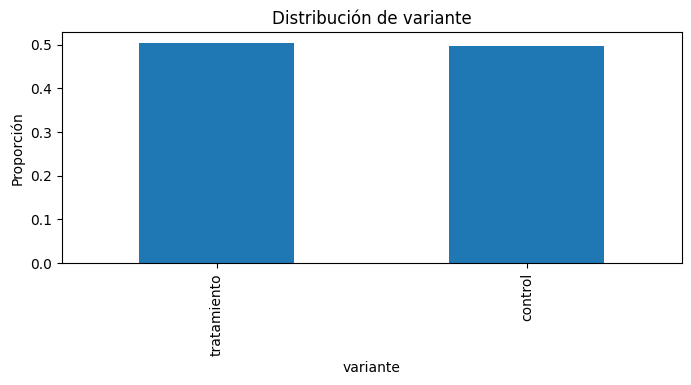

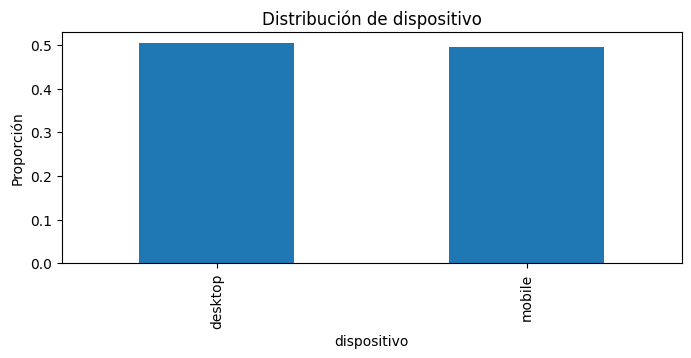

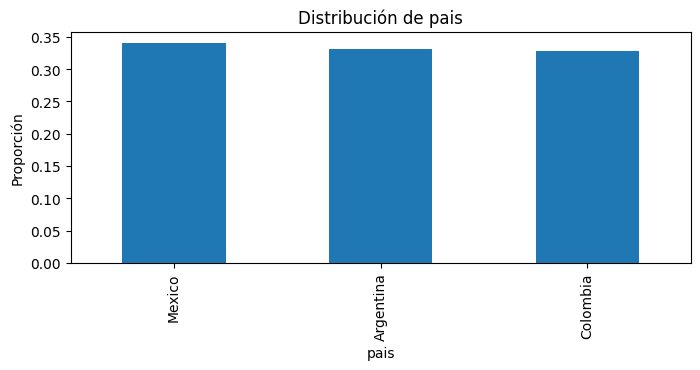

In [ ]:
#Conocer la población de variables categóricas
for col in ["variante","dispositivo","pais"]:
    proporciones=experimento[col].value_counts(normalize=True)

    plt.figure(figsize=(8, 3))
    proporciones.plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.show()




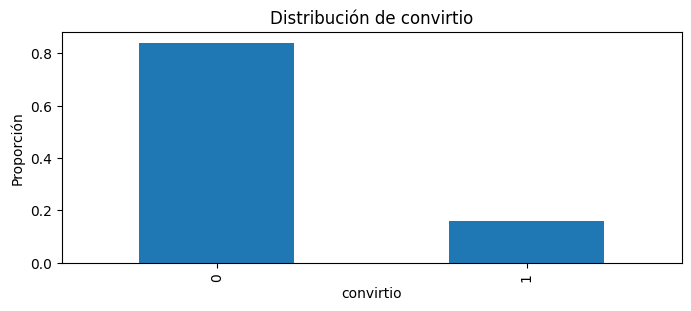

In [ ]:
#Conocer la población de variables numéricas
for col in ["convirtio","duracion_sesion"]:
    proporciones_num=experimento[col].value_counts(normalize=True)

    plt.figure(figsize=(8, 3))
    proporciones_num.plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.show()

In [ ]:
#Calcular tasas de conversión (control y tratamiento)

#dividir dataset de acuerdo a la variante
grupo_control = experimento[experimento["variante"] == "control"]
grupo_tratamiento = experimento[experimento["variante"] == "tratamiento"]
#obtener tamaño de cada grupo
n_c, n_t = len(grupo_control), len(grupo_tratamiento)
#contar cuantas conversiones tuvo cada grupo
conv_c, conv_t = grupo_control["convirtio"].sum(), grupo_tratamiento["convirtio"].sum()
#calcular tasas de conversion para control y tratamiento
tasa_c, tasa_t = conv_c / n_c, conv_t / n_t

print(f"\nControl:     {conv_c} conversiones de {n_c} usuarios -> tasa de conversión:  {tasa_c*100:.2f}%")
print(f"Tratamiento: {conv_t} conversiones de {n_t} usuarios -> tasa de conversión: {tasa_t*100:.2f}%")


In [ ]:
#Aplicar prueba Z
from statsmodels.stats.proportion import proportions_ztest

# Pasar los valores a formato lista
exitos = [conv_c, conv_t]
observaciones = [n_c,n_t]

#Aplicar prueba y visualizar resultados
z_stat, p_value = proportions_ztest(exitos , observaciones)
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")



**Conclusión:** La prueba Z obtuvo un estadístico de z = -0.813 y un p-valor = 0.4161, mayor que el nivel de significancia establecido (α = 0.05). Por lo tanto, **no se rechaza H₀** y no existe evidencia estadísticamente significativa para afirmar que la UI del checkout modificada genere una mayor tasa de conversión que la UI actual.

Aunque puede existir una diferencia observada entre ambas versiones, **esta diferencia no es suficientemente grande desde el punto de vista estadístico** como para concluir que la nueva UI mejora la conversión. Con los datos disponibles, el cambio de diseño no demuestra un beneficio claro sobre la versión actual.

**Recomendación:** No implementar la nueva UI únicamente con base en esta prueba. Se recomienda si el cambio tiene interés estratégico, realizar una nueva prueba durante un periodo más prolongado. También sería conveniente analizar otros indicadores del checkout, como abandono, tiempo de finalización o errores, para determinar si la nueva interfaz aporta mejoras aunque no incremente significativamente la conversión.


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI
2. Revisar relaciones:

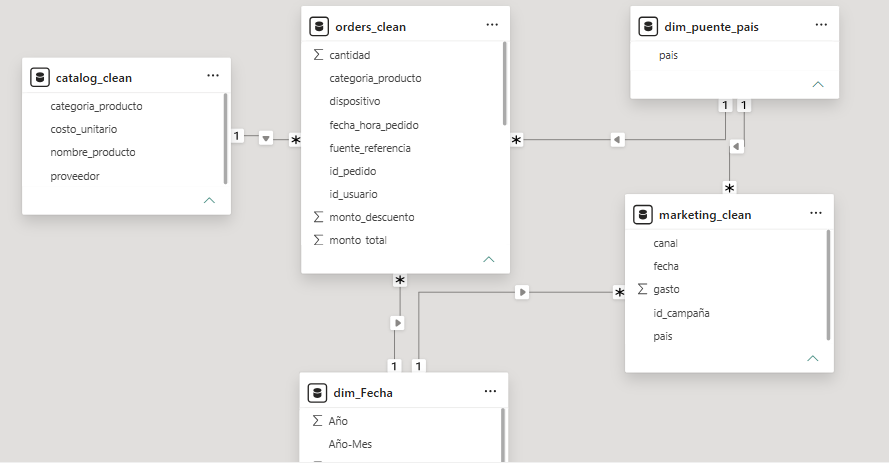

3. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

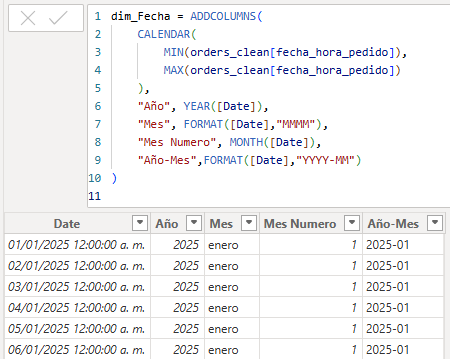

---

2️⃣ Dashboard 1: Overview Ejecutivo

**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto

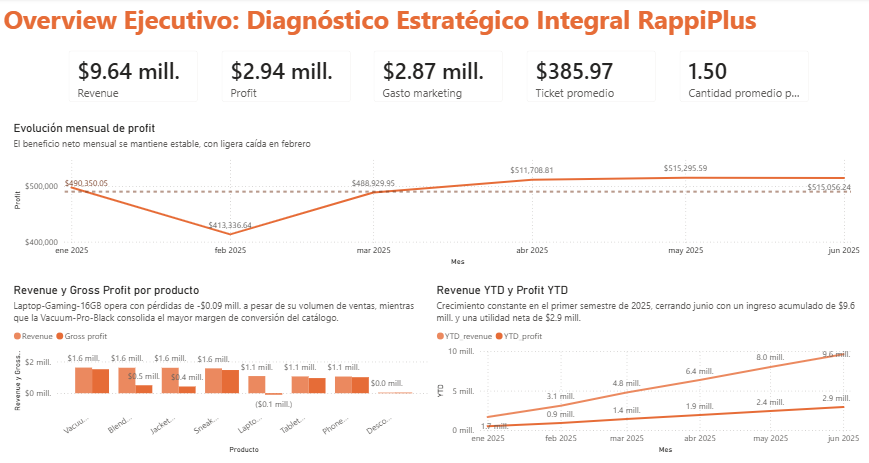

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

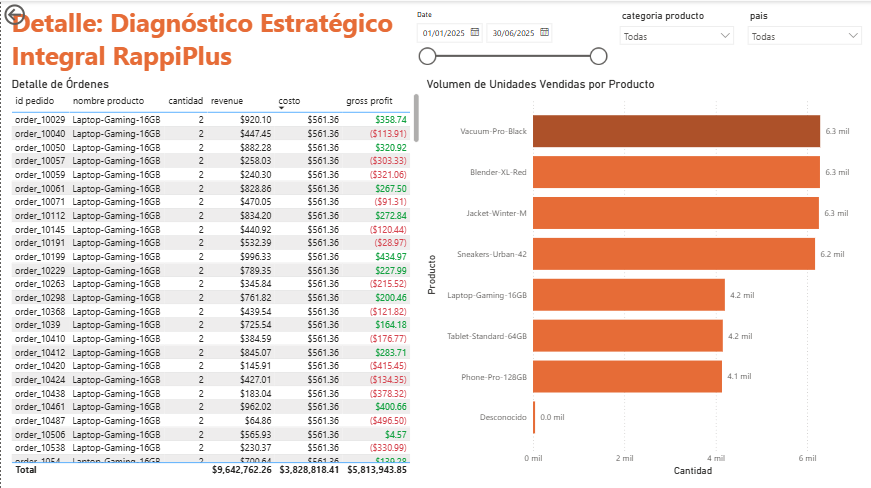

---

### 📎 Enlace del Dashboard

In [ ]:
# link de google drive
https://drive.google.com/drive/folders/18Z5Tzot72NF3Jxzcu2OroR-UOnMWOPjr?usp=sharing
